# Etapa 3: Aplicação de ML e Treinamento de Modelos

**ImunizaData**: segmentação e classificação de risco de baixa cobertura vacinal por município.

## Objetivo e escopo

Este notebook usa o dataset já limpo e cruzado da Etapa 2
(`refined/cobertura_vacinal`) para: (1) segmentar os municípios por
perfil socioeconômico e de cobertura via clusterização (K-Means), (2)
treinar um classificador de "baixa cobertura" usando características
demográficas, socioeconômicas e geográficas do município, e (3) explorar,
de forma complementar, um enquadramento de regressão sobre a mesma
cobertura contínua (seção 10).

**Recorte importante**: só temos um ano de dado processado (2025). O
objetivo original do projeto (`docs/entendimento_problema.md`, pergunta
5, e o README) fala em prever risco de baixa cobertura *futura*/"no
próximo ciclo" — isso exigiria treinar com features de um ano para
prever o resultado do ano seguinte. Sem um segundo ano de PNI/IBGE/PIB
processado, um modelo "preditivo de futuro" seria, na prática, treinado
e avaliado no mesmo ano. Por isso este notebook assume um objetivo mais
honesto com os dados disponíveis: **classificar o perfil de risco atual**
dos municípios (modelo transversal, não temporal). Essa limitação e o
caminho para superá-la ficam registrados na seção 9.

> Antes de rodar este notebook: garanta que a Etapa 2 já rodou
> (`notebooks/02_analise_exploratoria.ipynb` ou os comandos do README até
> `build_coverage.py`), e instale as dependências novas desta etapa:
> `pip install -r requirements.txt` (inclui `scikit-learn` e `xgboost`).

Decisões técnicas e de negócio desta etapa (definição do alvo,
algoritmos escolhidos e por quê, estratégia de split, limitações) estão
documentadas em detalhe em
[`docs/decisoes_modelagem.md`](../docs/decisoes_modelagem.md) — este
notebook foca na execução; o documento foca no raciocínio.

In [1]:
import io
import os
import sys
import time

sys.path.insert(0, os.path.abspath(".."))

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from botocore.client import Config

from src.config import MINIO_ACCESS_KEY, MINIO_ENDPOINT, MINIO_SECRET_KEY

sns.set_theme(style="whitegrid")

ANO = 2025
BUCKET_REFINED = os.getenv("MINIO_REFINED_BUCKET", "refined")

s3 = boto3.client(
    "s3",
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
    config=Config(signature_version="s3v4"),
)

key = f"cobertura_vacinal/ano={ANO}/cobertura_municipios.parquet"
obj = s3.get_object(Bucket=BUCKET_REFINED, Key=key)
df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
df.shape


(5571, 12)

## 1. Construção do dataset de features

Partimos das hipóteses registradas ao final do notebook 02 e das
colunas já disponíveis em `refined/cobertura_vacinal`:

- **Fronteira**: a análise exploratória (seção 3 do notebook 02) mostrou
  outliers de cobertura concentrados em municípios de fronteira
  (efeito "caravana da vacina"). Usamos a lista oficial de municípios da
  faixa de fronteira (IBGE 2024, Lei 6.634/1979 — sede do município
  dentro da faixa) quando ela já está disponível no dataset refinado
  (`clean_fronteira.py` via `build_coverage.py`); caso contrário, o
  notebook cai de volta numa aproximação por UF — os 11 estados que
  compõem a faixa de fronteira segundo o Ministério da Integração (AC,
  AP, AM, MT, MS, PA, PR, RS, RO, RR, SC), uma aproximação grosseira (um
  estado inteiro vira "1" mesmo que só uma fração dos seus municípios
  esteja de fato na faixa). Ver célula seguinte e limitações (seção 9).
- **Região**: a UF completa (27 categorias) provavelmente fragmentaria
  demais o dado por região para os modelos de árvore e explodiria o
  número de colunas do one-hot encoding para a Regressão Logística; a
  macrorregião (5 categorias) mantém sinal geográfico com bem menos
  esparsidade.
- **População e PIB per capita em log**: ambas as distribuições são bem
  assimétricas (seções 2 e 6 do notebook 02) — log1p aproxima a escala de
  uma distribuição mais tratável, o que ajuda sobretudo a Regressão
  Logística (sensível à escala das features).
- **Estabelecimentos de saúde (CNES), normalizado por população**: hipótese de que acesso a infraestrutura de saúde facilita a vacinação — mesma linha de raciocínio já usada para fronteira (sinal geográfico de acesso). Usamos só o subconjunto com atendimento ambulatorial SUS (`qtd_estabelecimentos_saude_sus`), não o total bruto do cadastro (que inclui, por exemplo, consultórios particulares e laboratórios — ver `docs/decisoes_limpeza.md`, seção 11), normalizado por população (por 100 mil habitantes, não a contagem bruta — senão a feature vira quase um proxy redundante de `log_populacao`) e log-transformado pelo mesmo motivo de população/PIB. **Diferente das quatro features originais**, essa não passou por uma etapa própria de exploração no notebook 02 antes de entrar aqui — foi adicionada depois, então a correlação com a cobertura é checada abaixo, na própria célula de construção, antes de decidir usá-la.
- **Densidade demográfica (IBGE/SIDRA)**: incluída **condicionalmente** — só entra no conjunto de features se a coluna `densidade_hab_km2` já existir no `refined` (depende de `download_area.py`/`clean_area.py` terem rodado; no momento em que esta versão do notebook foi escrita, a API do SIDRA estava temporariamente bloqueando as requisições do ambiente, então essa feature pode não estar disponível na sua execução — o notebook roda normalmente sem ela, só avisa). Mesma lógica de log-transform das demais variáveis numéricas.

**Alvo (`baixa_cobertura`)**: como definimos no início desta etapa, a
métrica de cobertura (doses por 100 habitantes) tem outliers extremos e
não é diretamente comparável a um padrão clínico fixo (ex.: 95% da OMS
para imunidade coletiva) — ver seção 2 do notebook 02. Por isso usamos um
corte estatístico relativo: município é `baixa_cobertura = 1` se está
abaixo do 1º quartil (25%) da distribuição nacional de cobertura. Isso
cria, por construção, um desbalanceamento de classes de
aproximadamente 25%/75%, tratado explicitamente no treinamento (seção 3).

In [ ]:
# Faixa de fronteira (Lei 6.634/1979): a lista oficial de municípios
# (IBGE 2024, sede dentro da faixa) é usada quando disponível no dataset
# refinado (`fronteira`, vinda de `clean_fronteira.py` via `build_coverage.py`);
# caso contrário, cai de volta na aproximação por UF abaixo — ver célula
# logo adiante e docs/decisoes_modelagem.md, seção 1.
UFS_FRONTEIRA = {"AC", "AP", "AM", "MT", "MS", "PA", "PR", "RS", "RO", "RR", "SC"}

REGIAO_POR_UF = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte",
    "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste",
    "PB": "Nordeste", "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste",
    "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}

colunas_obrigatorias = [
    "pib_per_capita_reais",
    "populacao",
    "cobertura_doses_por_100_habitantes",
    "qtd_estabelecimentos_saude_sus",
]
n_antes = len(df)
modelagem = df.dropna(subset=colunas_obrigatorias).copy()
print(f"Municípios descartados por falta de PIB/população/cobertura/CNES: {n_antes - len(modelagem)} de {n_antes}")

modelagem["uf"] = modelagem["municipio"].str.split(" - ").str[-1]

if "fronteira" in modelagem.columns:
    modelagem["fronteira"] = modelagem["fronteira"].astype(int)
    print(
        f"[INFO] Fronteira oficial (lista real do IBGE, 2024) disponível — "
        f"{int(modelagem['fronteira'].sum())} municípios com sede na faixa. "
        "Usada em vez da aproximação por UF."
    )
else:
    modelagem["fronteira"] = modelagem["uf"].isin(UFS_FRONTEIRA).astype(int)
    print(
        "[AVISO] Lista oficial de fronteira ainda não disponível no dataset "
        "refinado (rode download_fronteira.py + clean_fronteira.py + "
        "build_coverage.py e reexecute este notebook para incluí-la). "
        "Usando aproximação por UF (ver docs/decisoes_modelagem.md)."
    )

modelagem["regiao"] = modelagem["uf"].map(REGIAO_POR_UF)
assert modelagem["regiao"].isna().sum() == 0, "UF sem região mapeada — checar REGIAO_POR_UF"

modelagem["log_populacao"] = np.log1p(modelagem["populacao"])
modelagem["log_pib_per_capita"] = np.log1p(modelagem["pib_per_capita_reais"])

# CNES: normalizado por população (por 100 mil habitantes) — a contagem bruta
# de estabelecimentos é dominada pelo tamanho do município (ver seção 1),
# quase redundante com log_populacao. Só o subconjunto com atendimento
# ambulatorial SUS (proxy mais próximo de capacidade de vacinação do que o
# cadastro bruto, que inclui estabelecimentos sem relação com vacinação).
modelagem["estabelecimentos_saude_sus_por_100k_hab"] = (
    modelagem["qtd_estabelecimentos_saude_sus"] / modelagem["populacao"] * 100_000
)
modelagem["log_estabelecimentos_saude_sus_por_100k_hab"] = np.log1p(
    modelagem["estabelecimentos_saude_sus_por_100k_hab"]
)

FEATURES_NUMERICAS = ["log_populacao", "log_pib_per_capita", "fronteira", "log_estabelecimentos_saude_sus_por_100k_hab"]

# Área/densidade: condicional — só entra se `clean_area.py` já rodou (ver
# célula anterior e docs/decisoes_modelagem.md).
if "densidade_hab_km2" in modelagem.columns:
    modelagem["log_densidade_hab_km2"] = np.log1p(modelagem["densidade_hab_km2"])
    FEATURES_NUMERICAS.append("log_densidade_hab_km2")
    print("[INFO] Área/densidade disponível — incluída no conjunto de features.")
else:
    print(
        "[AVISO] Área/densidade ainda não disponível no dataset refinado "
        "(rode download_area.py + clean_area.py + build_coverage.py e "
        "reexecute este notebook para incluí-la). Prosseguindo sem essa feature."
    )

quartil_1 = modelagem["cobertura_doses_por_100_habitantes"].quantile(0.25)
modelagem["baixa_cobertura"] = (modelagem["cobertura_doses_por_100_habitantes"] < quartil_1).astype(int)

print(f"\n1º quartil nacional de cobertura: {quartil_1:.2f} doses por 100 habitantes")
print("Distribuição do alvo (baixa_cobertura):")
print(modelagem["baixa_cobertura"].value_counts(normalize=True).round(3))
print("\nMunicípios por região:")
print(modelagem["regiao"].value_counts())
print(f"\nMunicípios de fronteira (feature final): {modelagem['fronteira'].sum()} ({modelagem['fronteira'].mean():.1%})")

print("\nCorrelação das features numéricas novas com a cobertura (checagem antes de finalizar o conjunto):")
for candidata in ["log_estabelecimentos_saude_sus_por_100k_hab"] + (
    ["log_densidade_hab_km2"] if "log_densidade_hab_km2" in modelagem.columns else []
):
    corr = modelagem[candidata].corr(modelagem["cobertura_doses_por_100_habitantes"])
    print(f"  {candidata}: {corr:.3f}")

FEATURES_CATEGORICAS = ["regiao"]
ALVO = "baixa_cobertura"

X = modelagem[FEATURES_NUMERICAS + FEATURES_CATEGORICAS]
y = modelagem[ALVO]


## 2. Divisão treino / validação / teste

Com ~5.500 municípios, o dataset é grande o suficiente para um holdout
de três vias em vez de depender só de k-fold: **70% treino / 15%
validação / 15% teste**, estratificado pelo alvo (`stratify=y`) para
manter a mesma proporção de `baixa_cobertura` (~25%) nos três
conjuntos — sem estratificação, o desbalanceamento poderia deixar um
dos conjuntos com uma proporção bem diferente da população geral só por
acaso da amostragem.

Os papéis não se misturam: o **treino** ajusta os parâmetros do modelo;
a **validação** (junto com 5-fold cross-validation dentro do próprio
treino, na seção 3) escolhe os hiperparâmetros e o melhor modelo entre
os três candidatos; o **teste** só é usado uma única vez, no fim
(seção 5), para uma estimativa final não-viesada do modelo já escolhido.
Avaliar múltiplas vezes no teste e ajustar decisões a partir disso
vazaria informação do teste para o processo de escolha — é exatamente o
tipo de erro que a documentação explícita da estratégia de split busca
evitar.

In [3]:
from sklearn.model_selection import train_test_split

X_treino, X_temp, y_treino, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_teste, y_val, y_teste = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Treino:     {len(X_treino):5d} municípios ({len(X_treino) / len(X):.1%})")
print(f"Validação:  {len(X_val):5d} municípios ({len(X_val) / len(X):.1%})")
print(f"Teste:      {len(X_teste):5d} municípios ({len(X_teste) / len(X):.1%})")
print()
for nome_split, y_split in [("treino", y_treino), ("validação", y_val), ("teste", y_teste)]:
    print(f"  proporção de baixa_cobertura em {nome_split}: {y_split.mean():.3f}")


Treino:      3899 municípios (70.0%)
Validação:    835 municípios (15.0%)
Teste:        836 municípios (15.0%)

  proporção de baixa_cobertura em treino: 0.250
  proporção de baixa_cobertura em validação: 0.250
  proporção de baixa_cobertura em teste: 0.250


## 3. Treinamento e ajuste de hiperparâmetros

Treinamos três algoritmos de classificação, escolhidos para cobrir o
espectro do cardápio da disciplina — de um baseline simples e
explicável até modelos mais fortes e mais caros:

- **Regressão Logística**: baseline interpretável — cada coeficiente é
  diretamente lido como o efeito (em log-odds) de cada feature. É o
  ponto de referência: se um modelo mais complexo não superar isso por
  uma margem clara, a complexidade extra não se paga.
- **Random Forest**: ensemble de árvores, mais robusto a relações
  não-lineares e a outliers do que a Regressão Logística, com
  importância de features nativa.
- **XGBoost**: gradient boosting, tipicamente o mais forte dos três
  em problemas tabulares, mas o de maior custo computacional e
  interpretabilidade mais indireta — os três pontos de atenção que o
  material da disciplina associa a esse tipo de modelo (ver seção 8).

**Desbalanceamento de classes**: como `baixa_cobertura` é ~25% dos
municípios por construção (seção 1), todos os modelos usam
`class_weight="balanced"` (ou `scale_pos_weight` equivalente no
XGBoost) para não deixar o modelo simplesmente prever sempre a classe
majoritária — um modelo que sempre responde "não é baixa cobertura"
teria ~75% de acurácia e zero utilidade prática. É por isso, também,
que a métrica usada para escolher o melhor modelo (e para o tuning) é o
**F1** — que pondera precisão e recall — em vez de acurácia simples.

**Tuning**: `GridSearchCV` com 5-fold cross-validation dentro do
conjunto de treino, otimizando F1, para cada um dos três modelos.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Todas as features numéricas exceto "fronteira" (binária, não precisa de
# escala) entram no StandardScaler — lista dinâmica a partir de
# FEATURES_NUMERICAS (célula 3) em vez de hardcoded, para não esquecer de
# atualizar aqui se uma feature nova for adicionada/removida lá.
FEATURES_ESCALAR = [f for f in FEATURES_NUMERICAS if f != "fronteira"]

preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_ESCALAR),
        ("bin", "passthrough", ["fronteira"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["regiao"]),
    ]
)

# desbalanceamento: proporção negativo/positivo no próprio treino, usada no XGBoost
proporcao_negativo_positivo = (y_treino == 0).sum() / (y_treino == 1).sum()

MODELOS = {
    "Regressão Logística": (
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
        {"modelo__C": [0.01, 0.1, 1, 10]},
    ),
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        {"modelo__n_estimators": [200, 400], "modelo__max_depth": [4, 8, None]},
    ),
    "XGBoost": (
        XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=proporcao_negativo_positivo,
            random_state=42,
            n_jobs=-1,
        ),
        {
            "modelo__n_estimators": [200, 400],
            "modelo__max_depth": [3, 5, 7],
            "modelo__learning_rate": [0.05, 0.1],
        },
    ),
}

resultados = []
modelos_ajustados = {}

for nome, (estimador, grade) in MODELOS.items():
    pipeline = Pipeline([("preprocessador", preprocessador), ("modelo", estimador)])
    inicio = time.time()
    busca = GridSearchCV(pipeline, grade, scoring="f1", cv=5, n_jobs=-1)
    busca.fit(X_treino, y_treino)
    tempo_treino = time.time() - inicio

    melhor = busca.best_estimator_
    modelos_ajustados[nome] = melhor
    pred_val = melhor.predict(X_val)
    proba_val = melhor.predict_proba(X_val)[:, 1]

    resultados.append({
        "modelo": nome,
        "melhores_parametros": busca.best_params_,
        "accuracy": accuracy_score(y_val, pred_val),
        "precision": precision_score(y_val, pred_val),
        "recall": recall_score(y_val, pred_val),
        "f1": f1_score(y_val, pred_val),
        "roc_auc": roc_auc_score(y_val, proba_val),
        "tempo_treino_s": round(tempo_treino, 2),
    })
    print(f"{nome}: concluído em {tempo_treino:.1f}s — melhores parâmetros: {busca.best_params_}")


Regressão Logística: concluído em 3.9s — melhores parâmetros: {'modelo__C': 0.01}


Random Forest: concluído em 25.2s — melhores parâmetros: {'modelo__max_depth': 4, 'modelo__n_estimators': 200}


XGBoost: concluído em 9.7s — melhores parâmetros: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 200}


## 4. Matriz de comparação de modelos

Comparação dos três modelos no conjunto de **validação** (o teste
ainda não foi usado — ver seção 2), incluindo o tempo de treinamento
como proxy de custo computacional, um dos pontos de atenção explícitos
da disciplina.

**Sobre o KNN, testado e removido desta comparação:** uma versão
anterior deste notebook testou quatro algoritmos, incluindo KNN. Ele
foi removido da versão final por três motivos, não só um: (1) teve o
pior F1 de validação da comparação (0,188, contra 0,405–0,418 dos
demais); (2) mostrou o padrão clássico de um modelo enviesado para a
classe majoritária sob desbalanceamento — a **maior** acurácia (0,690)
e, ao mesmo tempo, o **menor** recall (0,144) da comparação, ou seja,
acerta muito só porque quase sempre prevê "não é baixa cobertura"; e
(3), mais importante que os dois números acima, a comparação com ele
era estruturalmente desigual — `KNeighborsClassifier` do scikit-learn
não aceita o parâmetro `class_weight`, então, ao contrário dos outros
três modelos (que usam `class_weight="balanced"` ou `scale_pos_weight`
equivalente — ver seção 3), o KNN nunca recebeu o mesmo tratamento de
desbalanceamento de classes. Manter um modelo em desvantagem estrutural
na comparação e concluir que ele é "pior" seria uma leitura injusta dos
números.

In [5]:
tabela_comparacao = pd.DataFrame(resultados).sort_values("f1", ascending=False).reset_index(drop=True)
display(tabela_comparacao.drop(columns=["melhores_parametros"]))

nome_melhor = tabela_comparacao.iloc[0]["modelo"]
f1_melhor = tabela_comparacao.iloc[0]["f1"]
print(f"\nMelhor modelo por F1 na validação: {nome_melhor} (F1 = {f1_melhor:.3f})")

f1_baseline = tabela_comparacao.set_index("modelo").loc["Regressão Logística", "f1"]
if nome_melhor == "Regressão Logística":
    print("O baseline interpretável já é o melhor modelo: os demais não se pagaram pela complexidade extra.")
elif f1_melhor - f1_baseline < 0.03:
    print(
        f"{nome_melhor} venceu, mas por uma margem pequena sobre a Regressão Logística "
        f"(F1 {f1_melhor:.3f} vs. {f1_baseline:.3f}) — vale considerar se a perda de "
        "interpretabilidade compensa um ganho tão pequeno."
    )
else:
    print(
        f"{nome_melhor} superou a Regressão Logística por uma margem relevante "
        f"(F1 {f1_melhor:.3f} vs. {f1_baseline:.3f})."
    )


,modelo,accuracy,precision,recall,f1,roc_auc,tempo_treino_s
0,Random Forest,0.583234,0.321337,0.598086,0.418060,0.627352,25.22
1,Regressão Logística,0.538922,0.302691,0.645933,0.412214,0.591605,3.92
2,XGBoost,0.584431,0.315508,0.564593,0.404803,0.618708,9.72



Melhor modelo por F1 na validação: Random Forest (F1 = 0.418)
Random Forest venceu, mas por uma margem pequena sobre a Regressão Logística (F1 0.418 vs. 0.412) — vale considerar se a perda de interpretabilidade compensa um ganho tão pequeno.


## 5. Avaliação do modelo final no conjunto de teste

Agora sim usamos o conjunto de teste — a única vez neste notebook —
para uma estimativa final e não-viesada do modelo escolhido na seção 4:
matriz de confusão, curva ROC e importância de features (ou
coeficientes, no caso da Regressão Logística).

Random Forest no teste — F1: 0.391 | ROC-AUC: 0.591


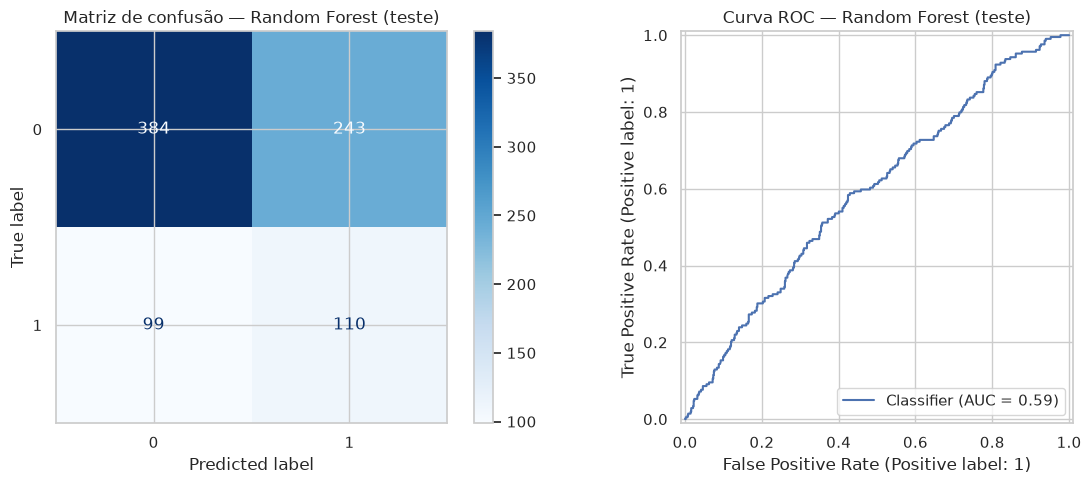

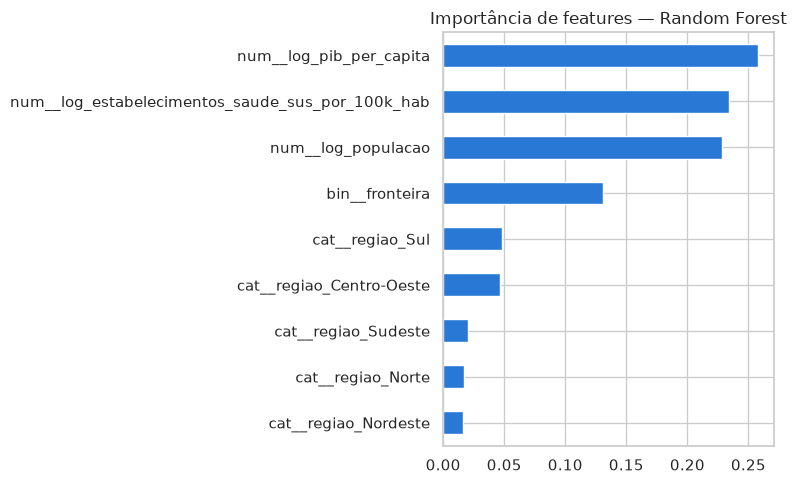

In [6]:
melhor_modelo = modelos_ajustados[nome_melhor]

pred_teste = melhor_modelo.predict(X_teste)
proba_teste = melhor_modelo.predict_proba(X_teste)[:, 1]
f1_teste = f1_score(y_teste, pred_teste)
roc_auc_teste = roc_auc_score(y_teste, proba_teste)
print(f"{nome_melhor} no teste — F1: {f1_teste:.3f} | ROC-AUC: {roc_auc_teste:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_teste, pred_teste, ax=axes[0], cmap="Blues")
axes[0].set_title(f"Matriz de confusão — {nome_melhor} (teste)")
RocCurveDisplay.from_predictions(y_teste, proba_teste, ax=axes[1])
axes[1].set_title(f"Curva ROC — {nome_melhor} (teste)")
plt.tight_layout()
plt.savefig("../reports/matriz_confusao_roc.png", dpi=150, bbox_inches="tight")
plt.show()


def nomes_features_pos_preprocessamento(pipeline):
    return pipeline.named_steps["preprocessador"].get_feature_names_out()


modelo_final = melhor_modelo.named_steps["modelo"]
nomes_features = nomes_features_pos_preprocessamento(melhor_modelo)

if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.Series(modelo_final.feature_importances_, index=nomes_features).sort_values(ascending=False)
    titulo_importancia = f"Importância de features — {nome_melhor}"
elif hasattr(modelo_final, "coef_"):
    importancias = pd.Series(modelo_final.coef_[0], index=nomes_features).abs().sort_values(ascending=False)
    titulo_importancia = f"|Coeficiente| — {nome_melhor} (proxy de importância)"
else:
    importancias = None

if importancias is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    importancias.head(10).sort_values().plot.barh(ax=ax, color="#2a78d6")
    ax.set_title(titulo_importancia)
    plt.tight_layout()
    plt.savefig("../reports/importancia_features.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"{nome_melhor} não tem importância de feature nativa nem coeficientes lineares.")


## 6. Checagem de overfitting

Sinal clássico de overfitting (citado explicitamente pela disciplina):
resultado ótimo no treino e ruim fora dele. Comparamos o F1 de cada
modelo no treino contra o F1 na validação (já calculado na seção 4).

In [7]:
def _interpretar_gap(gap: float) -> str:
    # abs(gap), não gap: um gap bem negativo (validação bem melhor que treino) não
    # é "pequeno" só porque é negativo — é tão atípico quanto um gap positivo grande,
    # só que na direção oposta (ver nota abaixo).
    magnitude = abs(gap)
    if magnitude < 0.05:
        return "gap pequeno — não sugere overfitting relevante"
    if gap > 0 and magnitude < 0.15:
        return "gap moderado — leve indício de overfitting, vale acompanhar"
    if gap > 0:
        return "gap grande — sinal de overfitting (o modelo memorizou padrões do treino que não generalizam)"
    return (
        "gap negativo e grande — validação bem melhor que treino, o que não é "
        "overfitting, mas também não é o padrão esperado; mais provável ser "
        "variância de amostra pequena do que um sinal de qualidade do modelo"
    )


tabela_comparacao_idx = tabela_comparacao.set_index("modelo")
linhas_overfitting = []
for nome, modelo in modelos_ajustados.items():
    f1_treino_modelo = f1_score(y_treino, modelo.predict(X_treino))
    f1_val_modelo = tabela_comparacao_idx.loc[nome, "f1"]
    gap = f1_treino_modelo - f1_val_modelo
    linhas_overfitting.append({"modelo": nome, "f1_treino": f1_treino_modelo, "f1_validacao": f1_val_modelo, "gap": gap})
    print(f"{nome}: F1 treino={f1_treino_modelo:.3f} | F1 validação={f1_val_modelo:.3f} | {_interpretar_gap(gap)}")

tabela_overfitting = pd.DataFrame(linhas_overfitting).sort_values("gap", ascending=False)
display(tabela_overfitting)


Regressão Logística: F1 treino=0.417 | F1 validação=0.412 | gap pequeno — não sugere overfitting relevante
Random Forest: F1 treino=0.450 | F1 validação=0.418 | gap pequeno — não sugere overfitting relevante
XGBoost: F1 treino=0.487 | F1 validação=0.405 | gap moderado — leve indício de overfitting, vale acompanhar


,modelo,f1_treino,f1_validacao,gap
2,XGBoost,0.486776,0.404803,0.081974
1,Random Forest,0.449808,0.418060,0.031747
0,Regressão Logística,0.416640,0.412214,0.004426


## 7. Clusterização (K-Means): segmentação por perfil

Além de classificar risco, o README também promete segmentar
municípios por perfil de cobertura e características socioeconômicas —
um problema não-supervisionado, então não usa o alvo `baixa_cobertura`
nem o split da seção 2 (K-Means não tem "resposta certa" para
validar). Usamos as três variáveis mais diretamente relacionadas ao
objetivo de negócio (população, PIB per capita e a própria cobertura,
todas padronizadas — K-Means é sensível à escala), escolhendo o número
de clusters *k* pelo silhouette score (não pelo método do cotovelo por si
só): o cotovelo (inércia) também é plotado, mas só como apoio visual --
com poucos clusters bem separados como neste caso, o cotovelo tende a ser
pouco nítido, então quem decide de fato *k* aqui é o maior silhouette
score entre os valores testados (ver `docs/decisoes_modelagem.md`).

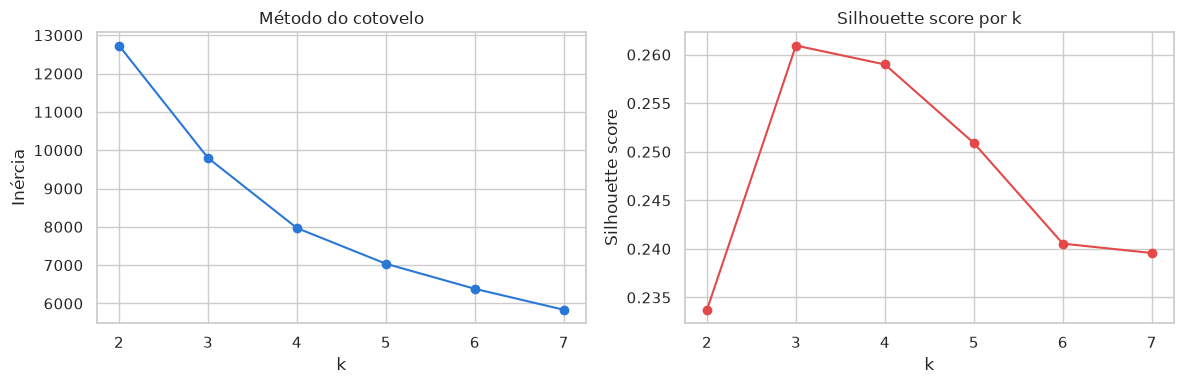

k escolhido (maior silhouette score): 3


,n_municipios,cobertura_media,populacao_mediana,pib_per_capita_medio,pct_fronteira
cluster,,,,,
0,2278,75.57,11551.5,18797.41,0.13
1,1198,80.99,52338.0,57686.47,0.36
2,2094,95.61,5709.0,50354.93,0.48


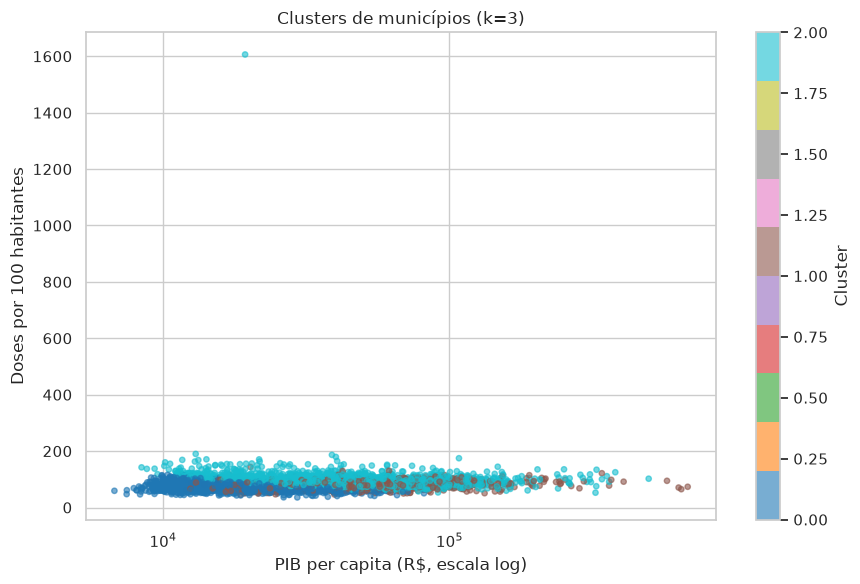


Cluster 0 é o de menor cobertura média (75.6 doses/100 hab.), com 2278 municípios, população mediana de 11.551 habitantes e PIB per capita médio de R$ 18.797 — candidato natural a prioridade em campanhas de imunização.

Cluster 2 é o de maior cobertura média (95.6 doses/100 hab.), com 2094 municípios, população mediana de 5.709 habitantes e PIB per capita médio de R$ 50.355.
Atenção: este é também o cluster de menor população mediana entre os 3 — a seção 5 do notebook 02 já mostrou que municípios pequenos têm métrica de cobertura mais volátil (poucas doses já mudam bastante o percentual). A cobertura mais alta deste cluster pode ser, em parte, esse efeito de volatilidade, não necessariamente melhor acesso real à vacinação — vale investigar antes de tratar este cluster como referência de boa cobertura.


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

FEATURES_CLUSTER = ["log_populacao", "log_pib_per_capita", "cobertura_doses_por_100_habitantes"]
X_cluster = modelagem[FEATURES_CLUSTER].copy()
X_cluster["cobertura_doses_por_100_habitantes"] = np.log1p(X_cluster["cobertura_doses_por_100_habitantes"])

scaler_cluster = StandardScaler()
X_cluster_padronizado = scaler_cluster.fit_transform(X_cluster)

valores_k = range(2, 8)
inercias, silhuetas = [], []
for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_padronizado)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_cluster_padronizado, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(valores_k), inercias, marker="o", color="#2a78d6")
axes[0].set_title("Método do cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")
axes[1].plot(list(valores_k), silhuetas, marker="o", color="#e34948")
axes[1].set_title("Silhouette score por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../reports/cotovelo_silhueta.png", dpi=150, bbox_inches="tight")
plt.show()

k_escolhido = list(valores_k)[int(np.argmax(silhuetas))]
print(f"k escolhido (maior silhouette score): {k_escolhido}")

kmeans_final = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
modelagem["cluster"] = kmeans_final.fit_predict(X_cluster_padronizado)

perfil_clusters = modelagem.groupby("cluster").agg(
    n_municipios=("codigo_municipio", "count"),
    cobertura_media=("cobertura_doses_por_100_habitantes", "mean"),
    populacao_mediana=("populacao", "median"),
    pib_per_capita_medio=("pib_per_capita_reais", "mean"),
    pct_fronteira=("fronteira", "mean"),
).round(2)
display(perfil_clusters)

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    modelagem["pib_per_capita_reais"], modelagem["cobertura_doses_por_100_habitantes"],
    c=modelagem["cluster"], cmap="tab10", alpha=0.6, s=15,
)
ax.set_xscale("log")
ax.set_xlabel("PIB per capita (R$, escala log)")
ax.set_ylabel("Doses por 100 habitantes")
ax.set_title(f"Clusters de municípios (k={k_escolhido})")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.savefig("../reports/clusters.png", dpi=150, bbox_inches="tight")
plt.show()

cluster_menor_cobertura = perfil_clusters["cobertura_media"].idxmin()
cluster_maior_cobertura = perfil_clusters["cobertura_media"].idxmax()
linha_menor = perfil_clusters.loc[cluster_menor_cobertura]
linha_maior = perfil_clusters.loc[cluster_maior_cobertura]

# separador de milhar no padrão BR (ponto), aplicado só aos números formatados,
# não à frase inteira — senão as vírgulas de pontuação também virariam ponto
populacao_fmt = f"{int(linha_menor['populacao_mediana']):,}".replace(",", ".")
pib_fmt = f"{linha_menor['pib_per_capita_medio']:,.0f}".replace(",", ".")

print(
    f"\nCluster {cluster_menor_cobertura} é o de menor cobertura média "
    f"({linha_menor['cobertura_media']:.1f} doses/100 hab.), com "
    f"{int(linha_menor['n_municipios'])} municípios, população mediana de "
    f"{populacao_fmt} habitantes e PIB per capita médio de R$ {pib_fmt} — "
    "candidato natural a prioridade em campanhas de imunização."
)

populacao_fmt_maior = f"{int(linha_maior['populacao_mediana']):,}".replace(",", ".")
pib_fmt_maior = f"{linha_maior['pib_per_capita_medio']:,.0f}".replace(",", ".")
print(
    f"\nCluster {cluster_maior_cobertura} é o de maior cobertura média "
    f"({linha_maior['cobertura_media']:.1f} doses/100 hab.), com "
    f"{int(linha_maior['n_municipios'])} municípios, população mediana de "
    f"{populacao_fmt_maior} habitantes e PIB per capita médio de R$ {pib_fmt_maior}."
)

if linha_maior["populacao_mediana"] == perfil_clusters["populacao_mediana"].min():
    print(
        "Atenção: este é também o cluster de menor população mediana entre os "
        f"{k_escolhido} — a seção 5 do notebook 02 já mostrou que municípios "
        "pequenos têm métrica de cobertura mais volátil (poucas doses já mudam "
        "bastante o percentual). A cobertura mais alta deste cluster pode ser, em "
        "parte, esse efeito de volatilidade, não necessariamente melhor acesso "
        "real à vacinação — vale investigar antes de tratar este cluster como "
        "referência de boa cobertura."
    )


## 8. Interpretação final

Fechando com as perguntas que a disciplina pede explicitamente:

**O modelo está sofrendo overfitting?** Ver a leitura por modelo na
seção 6 — o gap treino/validação de cada um já indica isso
diretamente; um gap grande é mais esperado em Random Forest e XGBoost
(mais flexíveis, mais propensos a se ajustar demais ao treino) do que
na Regressão Logística.

**O modelo generaliza bem?** A métrica de teste (seção 5) foi vista uma
única vez, depois de toda a escolha de modelo/hiperparâmetro já ter
sido feita só com treino e validação — se o F1 do teste ficar muito
distante do F1 de validação da seção 4, isso é sinal de que a validação
não estava representando bem o comportamento fora da amostra.

**O modelo possui viés?** Duas camadas de viés a considerar. A primeira
é a que já documentamos na Etapa 2
(`docs/criterios_selecao_dados.md`): o modelo usa PIB per capita como
única variável socioeconômica, e essa variável já mostrou ser um proxy
fraco e distorcido por concentração industrial (ex.: municípios-sede de
refinaria) — um modelo treinado sobre ela pode aprender esse mesmo
viés, não uma relação real com o acesso à vacinação. A segunda é o
próprio recorte de "fronteira por UF" (seção 1): é uma aproximação
grosseira que pode atribuir o mesmo risco geográfico a municípios muito
distantes da fronteira de fato.

**O modelo é explicável?** A Regressão Logística é diretamente
interpretável via coeficientes; Random Forest e XGBoost oferecem
importância de features (uma explicação agregada, não por predição
individual) — os três modelos comparados na versão final têm algum
grau de explicabilidade nativa. O KNN, testado e removido da
comparação (seção 4), não tinha nem coeficiente nem importância
nativa — mais um ponto contra ele, além do desempenho e do
tratamento desigual de desbalanceamento já discutidos lá.

**Faz sentido para o negócio?** O objetivo declarado no início do
projeto (`docs/entendimento_problema.md`) é apoiar a priorização de
campanhas de imunização, não substituir o julgamento de um gestor de
saúde pública. Tanto a classificação (seção 5) quanto a clusterização
(seção 7) devem ser lidas como **apoio à decisão**: uma lista
priorizada de municípios para investigação e ação, não uma decisão
automática — sobretudo dado o viés potencial descrito acima.

## 9. Limitações e possíveis melhorias futuras

- **Escopo transversal, não temporal**: como registrado na introdução,
  este modelo classifica o perfil de risco *atual* dos municípios, não
  prevê o *futuro* — faltam dados de um segundo ano (PNI, IBGE e PIB)
  para treinar em ano N e validar em N+1, que seria a versão mais fiel
  ao objetivo original do projeto.
- ~~**Fronteira aproximada por UF**~~ (**resolvido, condicional à sua
  execução local**): a lista oficial de municípios da faixa de fronteira
  (IBGE 2024, Lei 6.634/1979) já está integrada ao pipeline
  (`download_fronteira.py`/`clean_fronteira.py`/`build_coverage.py` — ver
  célula da seção 1) e substitui a aproximação por UF automaticamente
  assim que a camada trusted correspondente existir. A fonte é um
  arquivo estático do GeoFTP do IBGE, bloqueado (WAF) para a rede deste
  ambiente de nuvem — o mesmo bloqueio já documentado para área
  territorial (seção 1) — então o arquivo raw precisa ser obtido por
  fora (rede local) e enviado manualmente ao MinIO na primeira vez; ver
  `docs/decisoes_limpeza.md`, seção 12.
- **Desbalanceamento tratado só por peso de classe**: `class_weight`/
  `scale_pos_weight` é a abordagem mais simples; técnicas de
  reamostragem (ex.: SMOTE) são uma melhoria possível, a testar com
  cautela para não gerar municípios sintéticos pouco realistas.
- **Custo computacional**: o Random Forest foi o modelo mais lento para
  ajustar nesta grade de hiperparâmetros — em um cenário com mais dados
  (ex.: granularidade mensal em vez de anual), o custo de re-treinar
  os três modelos cresceria de forma não-trivial.
- **Poucas features**: o dataset de modelagem tem só três variáveis
  numéricas de fato (população, PIB per capita, fronteira) além da
  região. A sazonalidade mensal identificada no notebook 02 (seção 7)
  não entrou como feature aqui porque o dataset `refined` usado nesta
  etapa é anual — incorporar o mês exigiria remodelar o pipeline de
  `refined` para preservar granularidade mensal por município, o que
  hoje não existe (ver `docs/decisoes_limpeza.md`, seção 2).

## 10. Enquadramento complementar: regressão da cobertura contínua

A classificação da seção 2 responde uma pergunta binária: "este
município está entre os piores 25% do país?" — útil para decidir um
corte simples, mas descarta informação por construção: um município com
8 doses/100 habitantes e outro com 24 (ambos abaixo do 1º quartil, ver
seção 2) recebem exatamente o mesmo rótulo, mesmo sendo situações bem
diferentes na prática.

Como enquadramento **complementar** — não um substituto; o alvo binário
continua sendo a entrega principal desta etapa —, treinamos os três
modelos com racional de negócio mais forte (seção 4: Random Forest e
XGBoost pela robustez a relações não-lineares, um modelo linear como
baseline interpretável; o KNN fica de fora aqui pelo mesmo motivo já
registrado na seção 4 — sem vantagem de negócio específica) prevendo
diretamente `cobertura_doses_por_100_habitantes` (contínua), em vez do
rótulo binário `baixa_cobertura`.

**Que pergunta isso responde e que valor gera:** um score contínuo
permite **rankear** municípios por urgência dentro do próprio grupo de
risco — relevante porque o orçamento de uma campanha de imunização
raramente cobre todos os municípios "baixa cobertura" ao mesmo tempo;
saber que um município está "um pouco" abaixo do corte e outro está
"muito" abaixo muda a ordem de prioridade de um jeito que a
classificação binária, sozinha, não mostra.

**Expectativa honesta, registrada antes de rodar:** a limitação de
fundo já documentada na seção 9 é a pobreza de features (só população,
PIB per capita e um sinal geográfico aproximado), não o formato do
alvo — não esperamos um salto de poder preditivo (R²) só por trocar
classificação por regressão. O ganho esperado aqui é uma ferramenta de
priorização mais granular, não uma correção do desempenho fraco já
registrado nas seções 4/5.

Reaproveitamos a mesma divisão treino/validação/teste da classificação
(mesmos municípios em cada conjunto, seção 3) — evita introduzir uma
segunda fonte de aleatoriedade e mantém as duas abordagens diretamente
comparáveis.


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

ALVO_REG = "cobertura_doses_por_100_habitantes"

y_treino_reg = modelagem.loc[X_treino.index, ALVO_REG]
y_val_reg = modelagem.loc[X_val.index, ALVO_REG]
y_teste_reg = modelagem.loc[X_teste.index, ALVO_REG]

# Mesma lista dinâmica da célula 7 (FEATURES_ESCALAR) — reaproveitada aqui
# em vez de duplicar a lista hardcoded de features numéricas.
preprocessador_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_ESCALAR),
        ("bin", "passthrough", ["fronteira"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["regiao"]),
    ]
)

MODELOS_REG = {
    "Ridge (linear)": (
        Ridge(random_state=42),
        {"modelo__alpha": [0.1, 1.0, 10.0, 100.0]},
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {"modelo__n_estimators": [200, 400], "modelo__max_depth": [4, 8, None]},
    ),
    "XGBoost": (
        XGBRegressor(random_state=42, n_jobs=-1),
        {
            "modelo__n_estimators": [200, 400],
            "modelo__max_depth": [3, 5, 7],
            "modelo__learning_rate": [0.05, 0.1],
        },
    ),
}

resultados_reg = []
modelos_ajustados_reg = {}

for nome, (estimador, grade) in MODELOS_REG.items():
    pipeline = Pipeline([("preprocessador", preprocessador_reg), ("modelo", estimador)])
    inicio = time.time()
    busca = GridSearchCV(pipeline, grade, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
    busca.fit(X_treino, y_treino_reg)
    tempo_treino = time.time() - inicio

    melhor = busca.best_estimator_
    modelos_ajustados_reg[nome] = melhor
    pred_val = melhor.predict(X_val)

    resultados_reg.append({
        "modelo": nome,
        "melhores_parametros": busca.best_params_,
        "rmse": mean_squared_error(y_val_reg, pred_val) ** 0.5,
        "mae": mean_absolute_error(y_val_reg, pred_val),
        "r2": r2_score(y_val_reg, pred_val),
        "tempo_treino_s": round(tempo_treino, 2),
    })
    print(f"{nome}: concluído em {tempo_treino:.1f}s — melhores parâmetros: {busca.best_params_}")


Ridge (linear): concluído em 0.5s — melhores parâmetros: {'modelo__alpha': 1.0}


Random Forest: concluído em 45.0s — melhores parâmetros: {'modelo__max_depth': 4, 'modelo__n_estimators': 200}


XGBoost: concluído em 11.2s — melhores parâmetros: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 200}


### Matriz de comparação (regressão, validação)

Mesmo espírito da seção 4: RMSE e MAE nas unidades originais (doses por
100 habitantes) e R² para checar quanto da variância a mais o modelo
explica em relação a só usar a média — critério de seleção aqui é RMSE
(menor é melhor), não F1 (não se aplica a alvo contínuo).


In [10]:
tabela_comparacao_reg = pd.DataFrame(resultados_reg).sort_values("rmse").reset_index(drop=True)
display(tabela_comparacao_reg.drop(columns=["melhores_parametros"]))

nome_melhor_reg = tabela_comparacao_reg.iloc[0]["modelo"]
rmse_melhor = tabela_comparacao_reg.iloc[0]["rmse"]
r2_melhor = tabela_comparacao_reg.iloc[0]["r2"]
print(
    f"\nMelhor modelo por RMSE na validação: {nome_melhor_reg} "
    f"(RMSE = {rmse_melhor:.2f} doses/100 hab. | R² = {r2_melhor:.3f})"
)
print(
    "\nLembrete de leitura: um R² baixo aqui é esperado e consistente com o "
    "F1/ROC-AUC fracos da classificação (seções 4/5) — mesmo conjunto pobre "
    "de features, problema de fundo diferente do formato do alvo."
)


,modelo,rmse,mae,r2,tempo_treino_s
0,Ridge (linear),54.662255,13.461501,0.015462,0.48
1,XGBoost,54.683251,13.314215,0.014706,11.16
2,Random Forest,54.764247,13.289363,0.011785,45.05



Melhor modelo por RMSE na validação: Ridge (linear) (RMSE = 54.66 doses/100 hab. | R² = 0.015)

Lembrete de leitura: um R² baixo aqui é esperado e consistente com o F1/ROC-AUC fracos da classificação (seções 4/5) — mesmo conjunto pobre de features, problema de fundo diferente do formato do alvo.


### Avaliação no teste

Mesma disciplina da seção 5: teste tocado uma única vez, só depois do
melhor modelo já escolhido pela validação acima.


Ridge (linear) no teste — RMSE: 15.81 | MAE: 11.90 | R²: 0.062


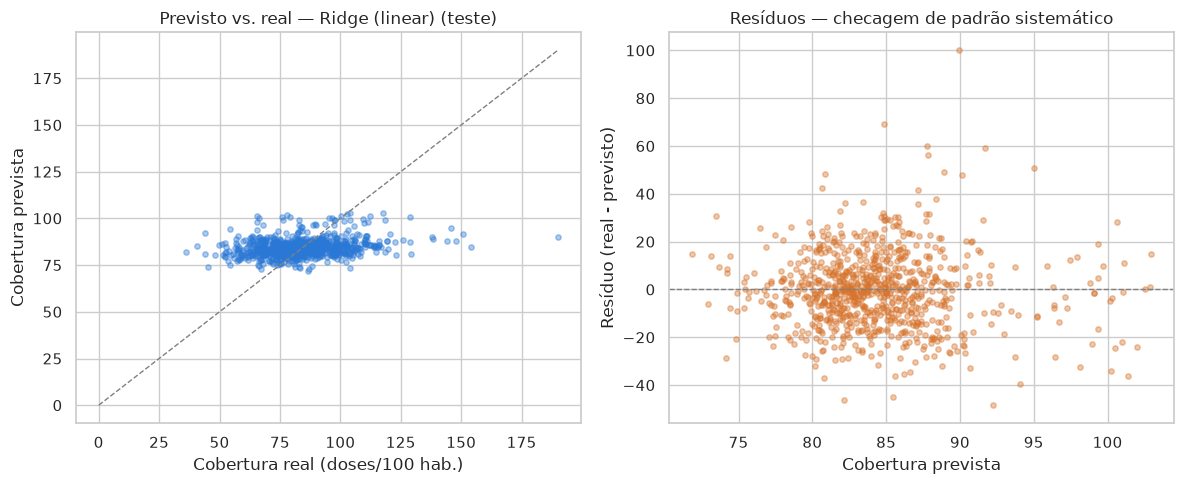

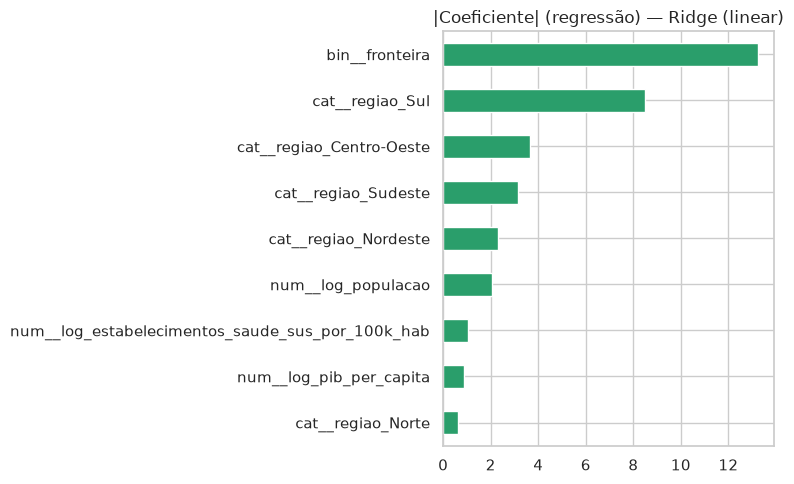

In [11]:
melhor_modelo_reg = modelos_ajustados_reg[nome_melhor_reg]

pred_teste_reg = melhor_modelo_reg.predict(X_teste)
rmse_teste = mean_squared_error(y_teste_reg, pred_teste_reg) ** 0.5
mae_teste = mean_absolute_error(y_teste_reg, pred_teste_reg)
r2_teste = r2_score(y_teste_reg, pred_teste_reg)
print(f"{nome_melhor_reg} no teste — RMSE: {rmse_teste:.2f} | MAE: {mae_teste:.2f} | R²: {r2_teste:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_teste_reg, pred_teste_reg, alpha=0.4, s=15, color="#2a78d6")
limite = max(y_teste_reg.max(), pred_teste_reg.max())
axes[0].plot([0, limite], [0, limite], "--", color="gray", linewidth=1)
axes[0].set_xlabel("Cobertura real (doses/100 hab.)")
axes[0].set_ylabel("Cobertura prevista")
axes[0].set_title(f"Previsto vs. real — {nome_melhor_reg} (teste)")

residuos = y_teste_reg - pred_teste_reg
axes[1].scatter(pred_teste_reg, residuos, alpha=0.4, s=15, color="#d6722a")
axes[1].axhline(0, linestyle="--", color="gray", linewidth=1)
axes[1].set_xlabel("Cobertura prevista")
axes[1].set_ylabel("Resíduo (real - previsto)")
axes[1].set_title("Resíduos — checagem de padrão sistemático")

plt.tight_layout()
plt.savefig("../reports/regressao_previsto_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()

nomes_features_reg = melhor_modelo_reg.named_steps["preprocessador"].get_feature_names_out()
modelo_final_reg = melhor_modelo_reg.named_steps["modelo"]

if hasattr(modelo_final_reg, "feature_importances_"):
    importancias_reg = pd.Series(
        modelo_final_reg.feature_importances_, index=nomes_features_reg
    ).sort_values(ascending=False)
    titulo_imp_reg = f"Importância de features (regressão) — {nome_melhor_reg}"
elif hasattr(modelo_final_reg, "coef_"):
    importancias_reg = pd.Series(
        modelo_final_reg.coef_, index=nomes_features_reg
    ).abs().sort_values(ascending=False)
    titulo_imp_reg = f"|Coeficiente| (regressão) — {nome_melhor_reg}"
else:
    importancias_reg = None

if importancias_reg is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    importancias_reg.head(10).sort_values().plot.barh(ax=ax, color="#2a9e6b")
    ax.set_title(titulo_imp_reg)
    plt.tight_layout()
    plt.savefig("../reports/importancia_features_regressao.png", dpi=150, bbox_inches="tight")
    plt.show()


### Leitura dos resultados

Compare o RMSE/MAE acima com a escala da própria métrica (doses por 100
habitantes, ver distribuição na seção 2 do notebook 02) para julgar se
o erro típico é ou não aceitável para priorização — um R² baixo não
torna o modelo inútil para **ordenar** municípios, mesmo que não sirva
para estimar a cobertura de um município específico com precisão.

Este enquadramento fica registrado como complementar à classificação
(seções 2 a 6), não como substituto: a decisão de "quais municípios
entram numa campanha" continua vindo do corte binário (mais simples de
comunicar a um gestor de saúde pública); o score contínuo desta seção
serve para desempatar a ordem **dentro** da lista já priorizada.
Decisão e racional completo em
[`docs/decisoes_modelagem.md`](../docs/decisoes_modelagem.md), seção 7.
